In [1]:
import numpy as np
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy import stats
import os
from stoch_sim_model import *
from optimize_nets import *
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

In [2]:
num_pnts = 10
runs = 5
infection_model = 'acute'
sample_virs = np.array(np.meshgrid(d_S*np.linspace(10, 125, num_pnts), # vary d_I
                                   K_IE*np.logspace(0.0, 3, num_pnts), # vary K_IE
                                   b_I*np.linspace(0.5, 2.0, num_pnts), # vary b_I
                                   K_EH*np.array([1.0]), # vary K_EH
                                   N_0*np.array([1.0]), # vary N_0
                                   I_0*np.array([1.0]) # vary I_0
                                       )).T.reshape(-1,6)

default_reg = act_psis + NE_psis + EM_psis + exp_psis

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"
# d="_local_data/"

In [3]:
# run simulations for extreme scenarios
run(batch = [-1], outdir=d, inf_sample = sample_virs, 
    comment="single-reg-vary-virs", runs = runs, infection_model = infection_model, default_reg = default_reg, 
    num_cpu = 100)

Running 5000 simulations in batch #-1
Saved sim_batch_-1-5-acute-single-reg-vary-virs.pkl
0.01296855734454261 hrs


In [4]:
d_file = d + '/sim_batch_-1-'+str(runs)+'-'+infection_model+'-single-reg-vary-virs.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

n = len(sample_virs)
parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]

In [5]:
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
sim_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]).dropna(thresh=1)
use_data = sim_df.loc[sim_df['b_I']*sim_df['S_0'] >= sim_df['d_I']]

with pd.option_context('display.max_columns', None):
    display(use_data)

,S_0,I_0,b_I,d_S,d_I,d_IE,K_IE,b_H,d_H,K_EH,N_0,max_Na,b_myc,d_myc,myc_thresh,t_bind,t_unbind,t_Na_div,t_E_div,t_M_div,t_E_die,t_act,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,p_load,T_max_pI,T_min_pI,harm_pI,harm_pS,max_pE,T_pE_max,T_pE_start,max_eM,T_eM_min,max_cM,T_cM_min,int_pP,int_pH,min_pS
0,10000000.0,1000.0,5.000000e-08,0.01,0.10,16.0,1.000000e+04,1.0,2.0,50000.0,300.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,-3.0,4.0,3.0,3.0,-3.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,-3.0,0.0,1.660653e+04,4.288,5.896,9.201799e+03,3.900632e+04,14976.0,6.504,4.208,1446.0,0.764848,124.0,5.0,23273.373429,8.303264e+02,9.991937e+06
1,10000000.0,1000.0,5.000000e-08,0.01,0.10,16.0,2.154435e+04,1.0,2.0,50000.0,300.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,-3.0,4.0,3.0,3.0,-3.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,-3.0,0.0,5.373142e+04,7.416,8.920,2.772573e+04,3.885961e+04,14313.0,9.184,6.728,1242.0,1.193545,218.0,5.0,30604.736692,2.686571e+03,9.973998e+06
2,10000000.0,1000.0,5.000000e-08,0.01,0.10,16.0,4.641589e+04,1.0,2.0,50000.0,300.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,-3.0,4.0,3.0,3.0,-3.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,-3.0,0.0,1.245604e+05,8.592,12.304,6.279543e+04,4.475796e+04,15712.0,11.624,7.600,1414.0,1.099378,209.0,5.0,47538.415549,6.227716e+03,9.940670e+06
3,10000000.0,1000.0,5.000000e-08,0.01,0.10,16.0,1.000000e+05,1.0,2.0,50000.0,300.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,-3.0,4.0,3.0,3.0,-3.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,-3.0,0.0,3.514600e+05,11.808,14.888,1.746578e+05,9.117078e+04,34022.0,13.040,10.104,1947.0,0.938795,259.0,5.0,115245.953902,1.757041e+04,9.833273e+06
4,10000000.0,1000.0,5.000000e-08,0.01,0.10,16.0,2.154435e+05,1.0,2.0,50000.0,300.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,-3.0,4.0,3.0,3.0,-3.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,-3.0,0.0,9.736449e+05,13.792,0.000,4.763780e+05,1.129682e+05,41197.0,15.072,12.104,1756.0,1.507066,438.0,5.0,223566.928941,4.775690e+04,9.555592e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,10000000.0,1000.0,2.000000e-07,0.01,1.25,16.0,4.641589e+05,1.0,2.0,50000.0,300.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,-3.0,4.0,3.0,3.0,-3.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,-3.0,0.0,8.607644e+05,8.448,10.872,1.584400e+06,5.738205e+05,245465.0,9.920,5.536,6033.0,0.908985,912.0,5.0,541129.750752,5.379777e+05,8.459990e+06
4996,10000000.0,1000.0,2.000000e-07,0.01,1.25,16.0,1.000000e+06,1.0,2.0,50000.0,300.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,-3.0,4.0,3.0,3.0,-3.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,-3.0,0.0,1.338458e+06,9.112,12.672,2.354303e+06,7.755171e+05,373928.0,10.408,7.336,5514.0,0.807016,771.0,5.0,728367.942293,8.365361e+05,7.720386e+06
4997,10000000.0,1000.0,2.000000e-07,0.01,1.25,16.0,2.154435e+06,1.0,2.0,50000.0,300.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,-3.0,4.0,3.0,3.0,-3.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,-3.0,0.0,2.033184e+06,9.816,0.000,3.355702e+06,9.987245e+05,534677.0,11.248,7.872,5446.0,0.782776,756.0,5.0,903612.212183,1.269073e+06,6.808476e+06
4998,10000000.0,1000.0,2.000000e-07,0.01,1.25,16.0,4.641589e+06,1.0,2.0,50000.0,300.0,4.0,4.0,1.0,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,-3.0,4.0,3.0,3.0,-3.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,-3.0,0.0,2.687247e+06,10.000,0.000,4.190374e+06,1.009275e+06,579967.0,11.272,7.600,2114.0,1.816793,729.0,5.0,900984.949481,1.667320e+06,6.209258e+06


### Understand noise structure of the simulations

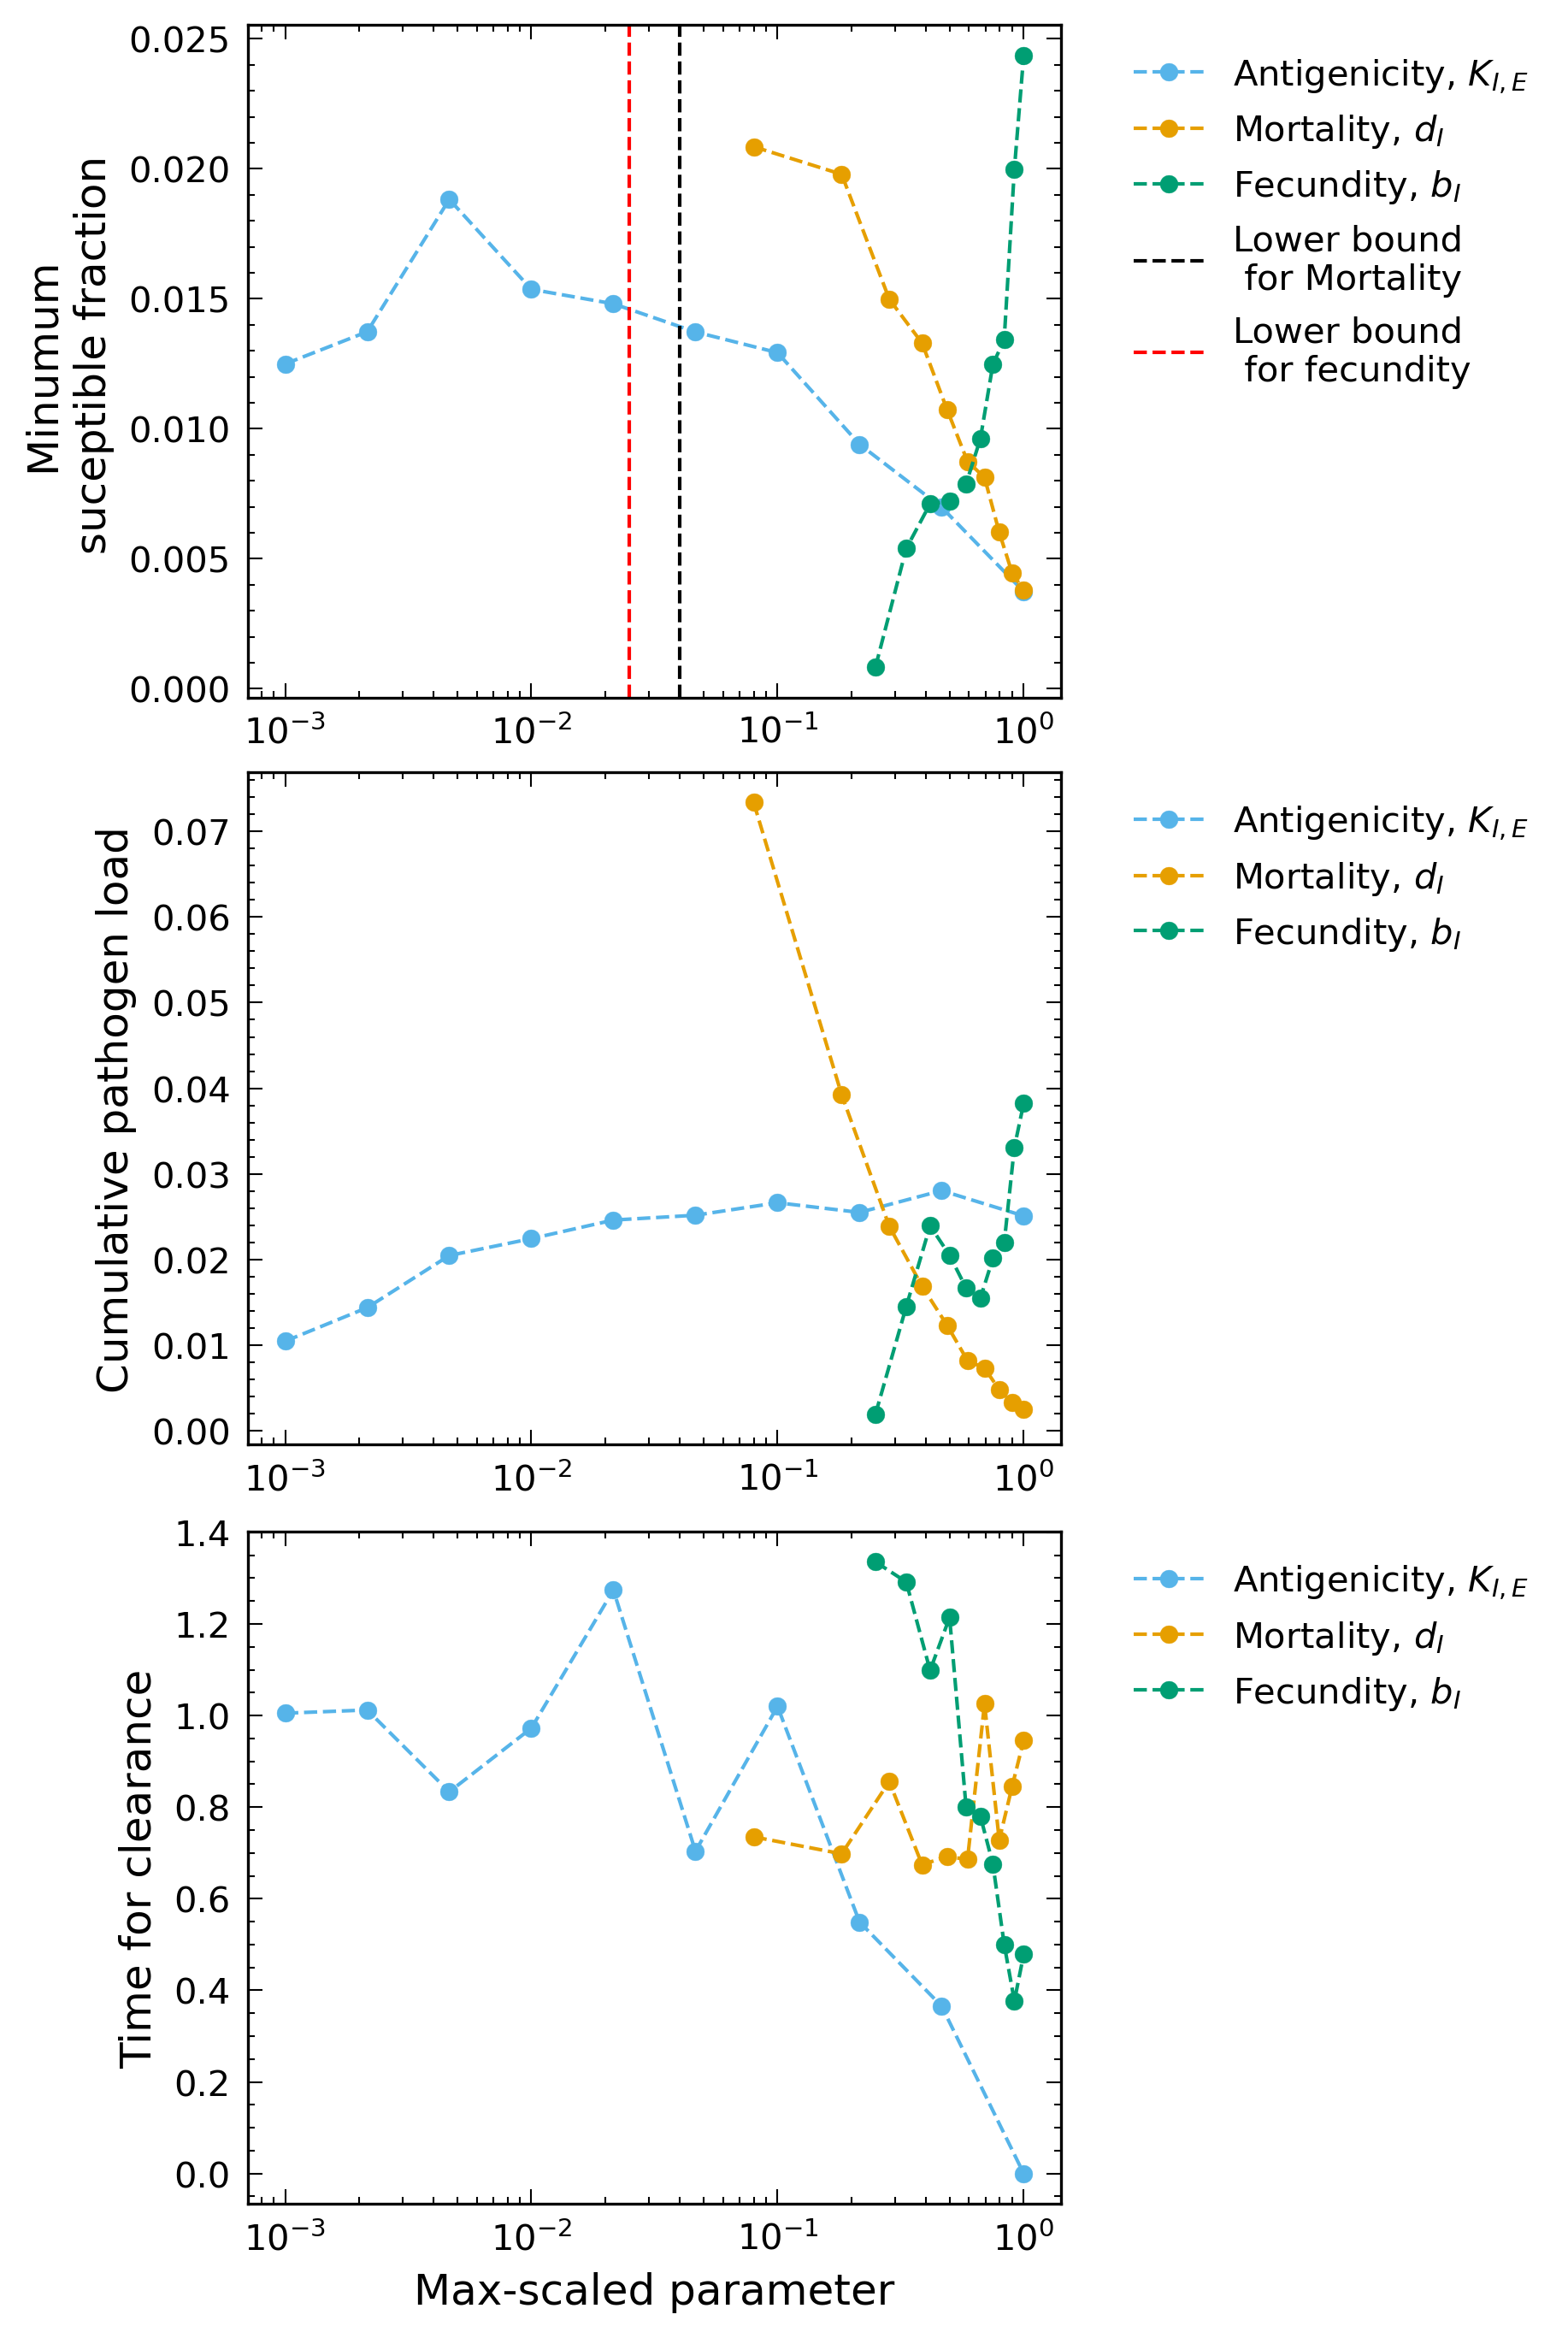

In [6]:
if runs > 1:
    # Plot simulated immune dynamics
    fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(6,9))
    
    ax1.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['K_IE'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
    ax1.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['d_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Mortality, $d_{I}$')
    ax1.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
    ax1.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Mortality")
    ax1.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
    ax1.semilogx()
    ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    ax1.set(ylabel = 'Minumum \n suceptible fraction')
    
    ax2.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['K_IE'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
    ax2.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['d_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Mortality, $d_{I}$')
    ax2.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
    ax2.semilogx()
    ax2.set(ylabel = 'Cumulative pathogen load')
    ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    
    ax3.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['K_IE'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Antigenicity, $K_{I,E}$')
    ax3.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['d_I'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Mortality, $d_{I}$')
    ax3.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Fecundity, $b_{I}$')
    ax3.set(ylabel = 'Time for clearance', xlabel = 'Max-scaled parameter')
    ax3.semilogx()
    ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    
    
    plt.savefig('_figs/vir_parameter_lineplots_noise', dpi=300, bbox_inches='tight')

### Understand Performance distrubution of the simulations

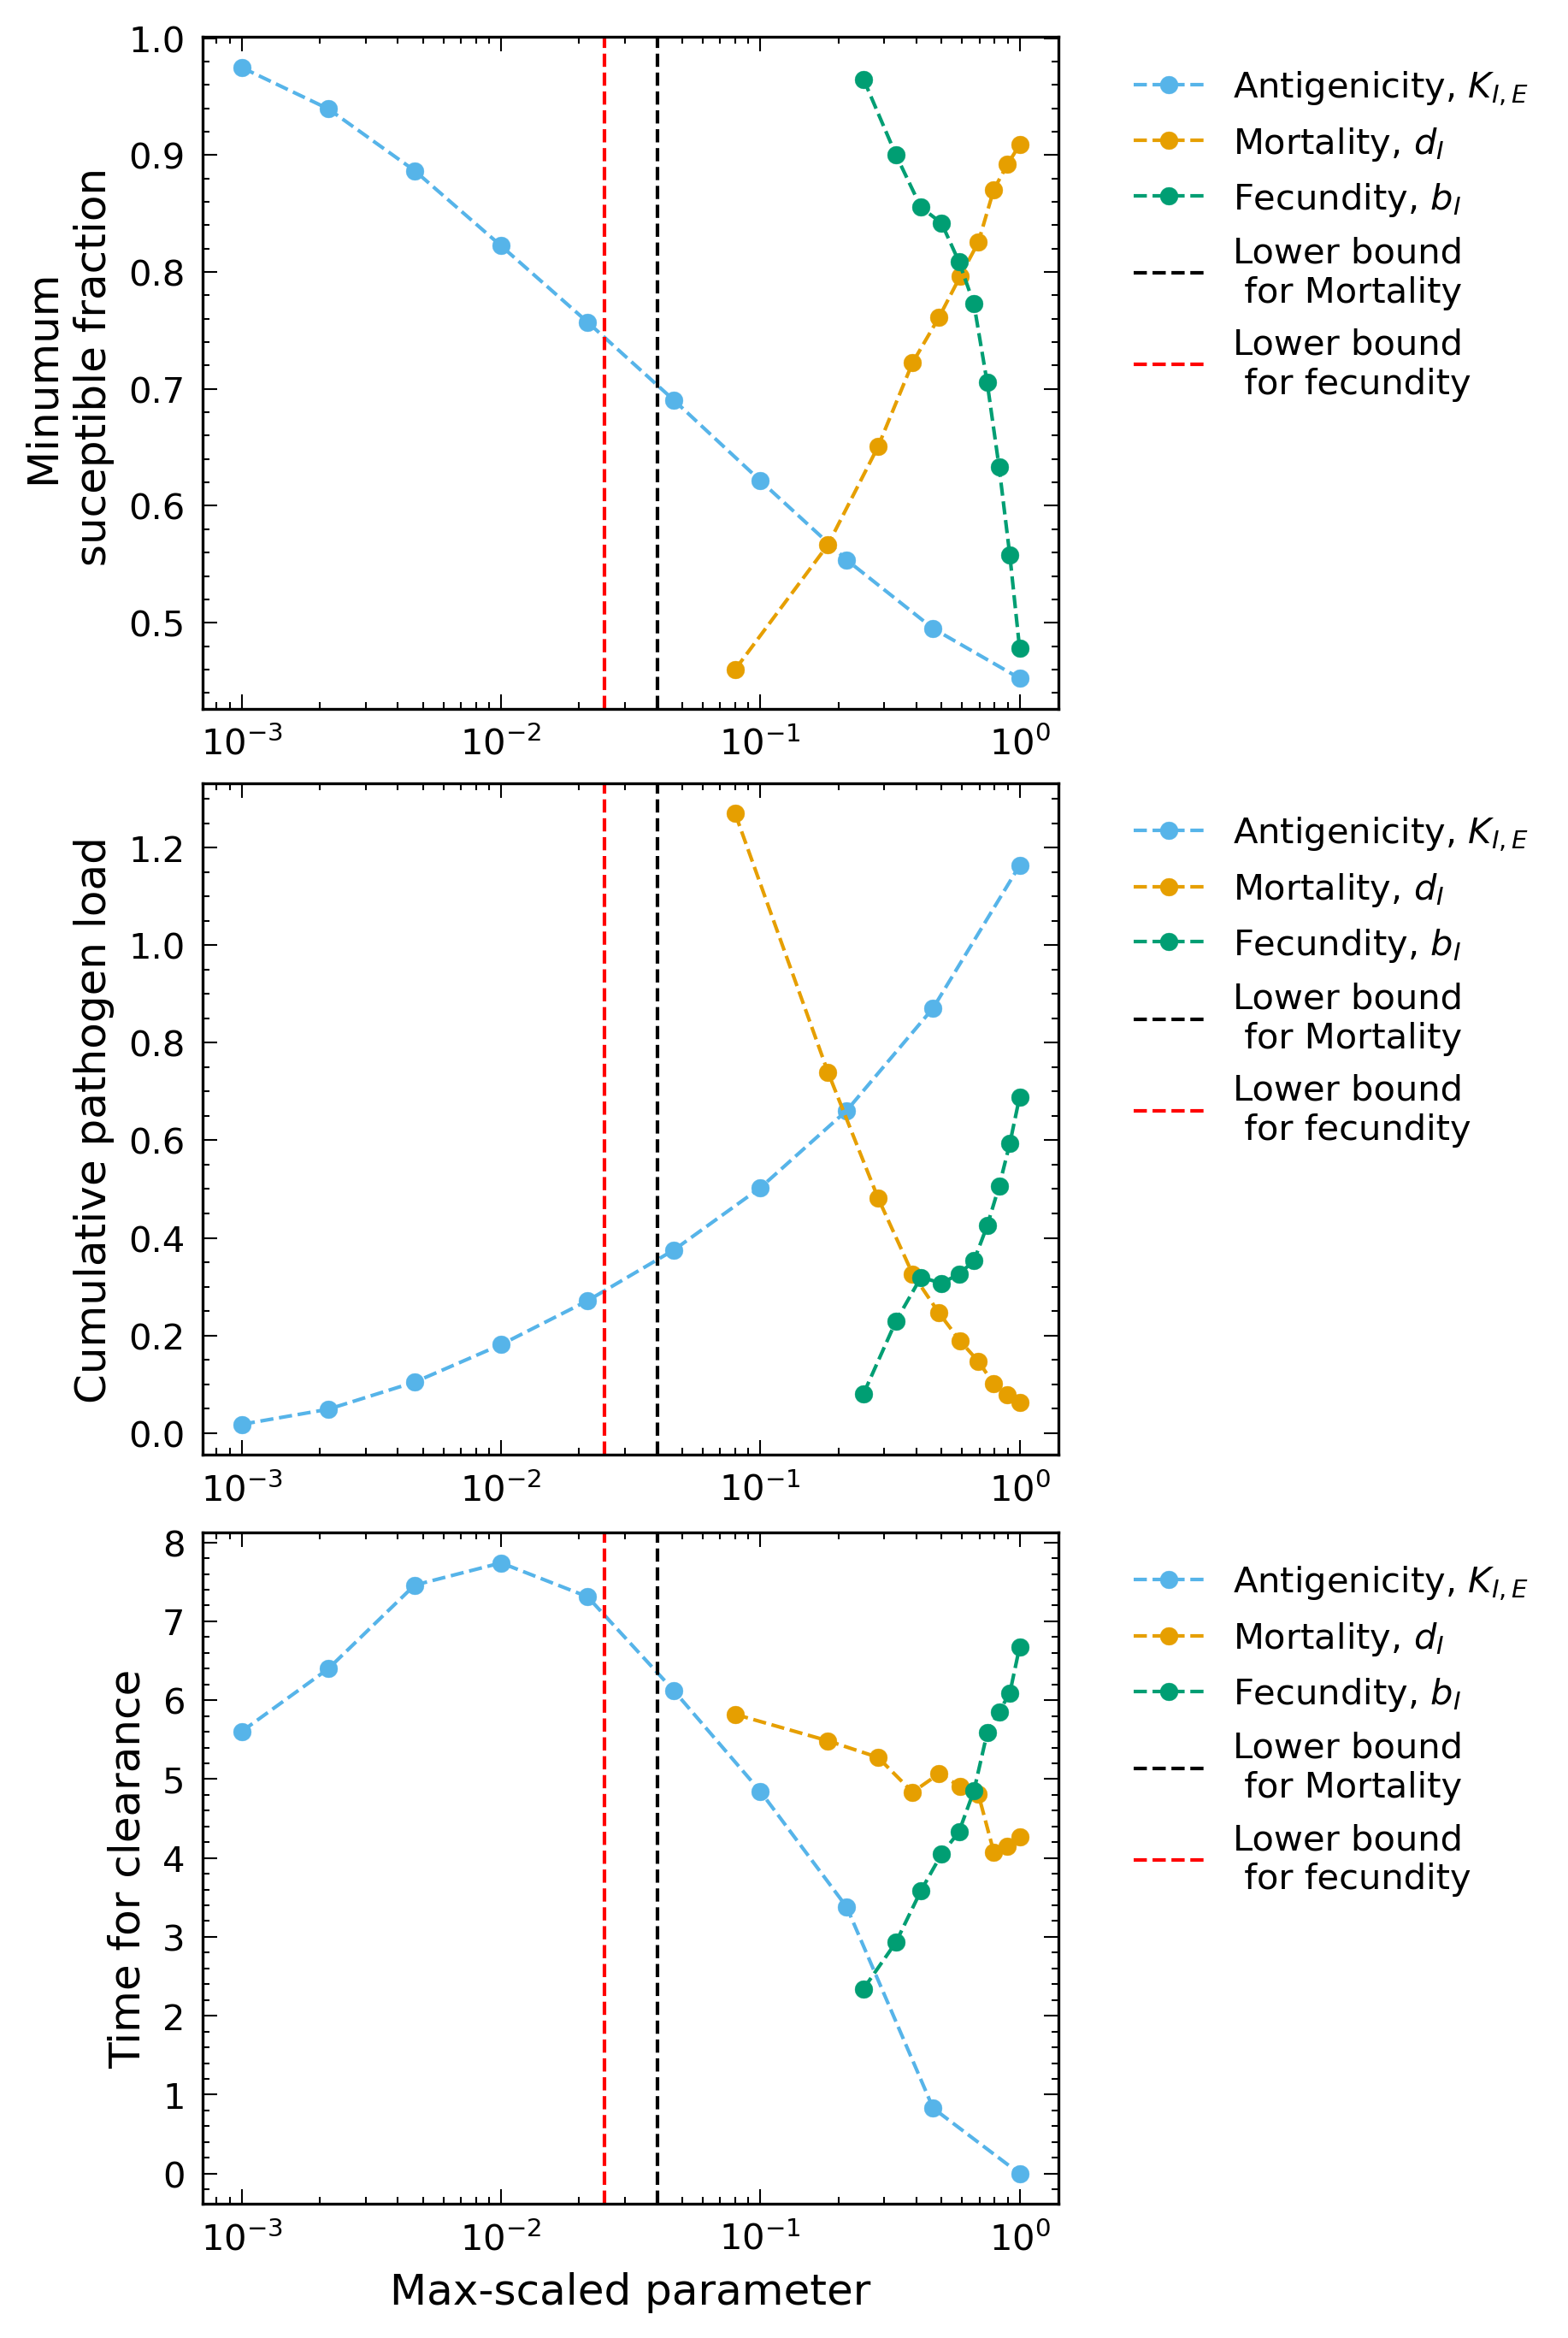

In [7]:
# Plot simulated immune dynamics
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(6,9))

ax1.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
ax1.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Mortality, $d_{I}$')
ax1.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
ax1.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Mortality")
ax1.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax1.semilogx()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
ax1.set(ylabel = 'Minumum \n suceptible fraction')

ax2.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
ax2.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Mortality, $d_{I}$')
ax2.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
ax2.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Mortality")
ax2.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax2.semilogx()
ax2.set(ylabel = 'Cumulative pathogen load')
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Antigenicity, $K_{I,E}$')
ax3.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Mortality, $d_{I}$')
ax3.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Fecundity, $b_{I}$')
ax3.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Mortality")
ax3.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax3.set(ylabel = 'Time for clearance', xlabel = 'Max-scaled parameter')
ax3.semilogx()
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')


plt.savefig('_figs/vir_parameter_lineplots', dpi=300, bbox_inches='tight')

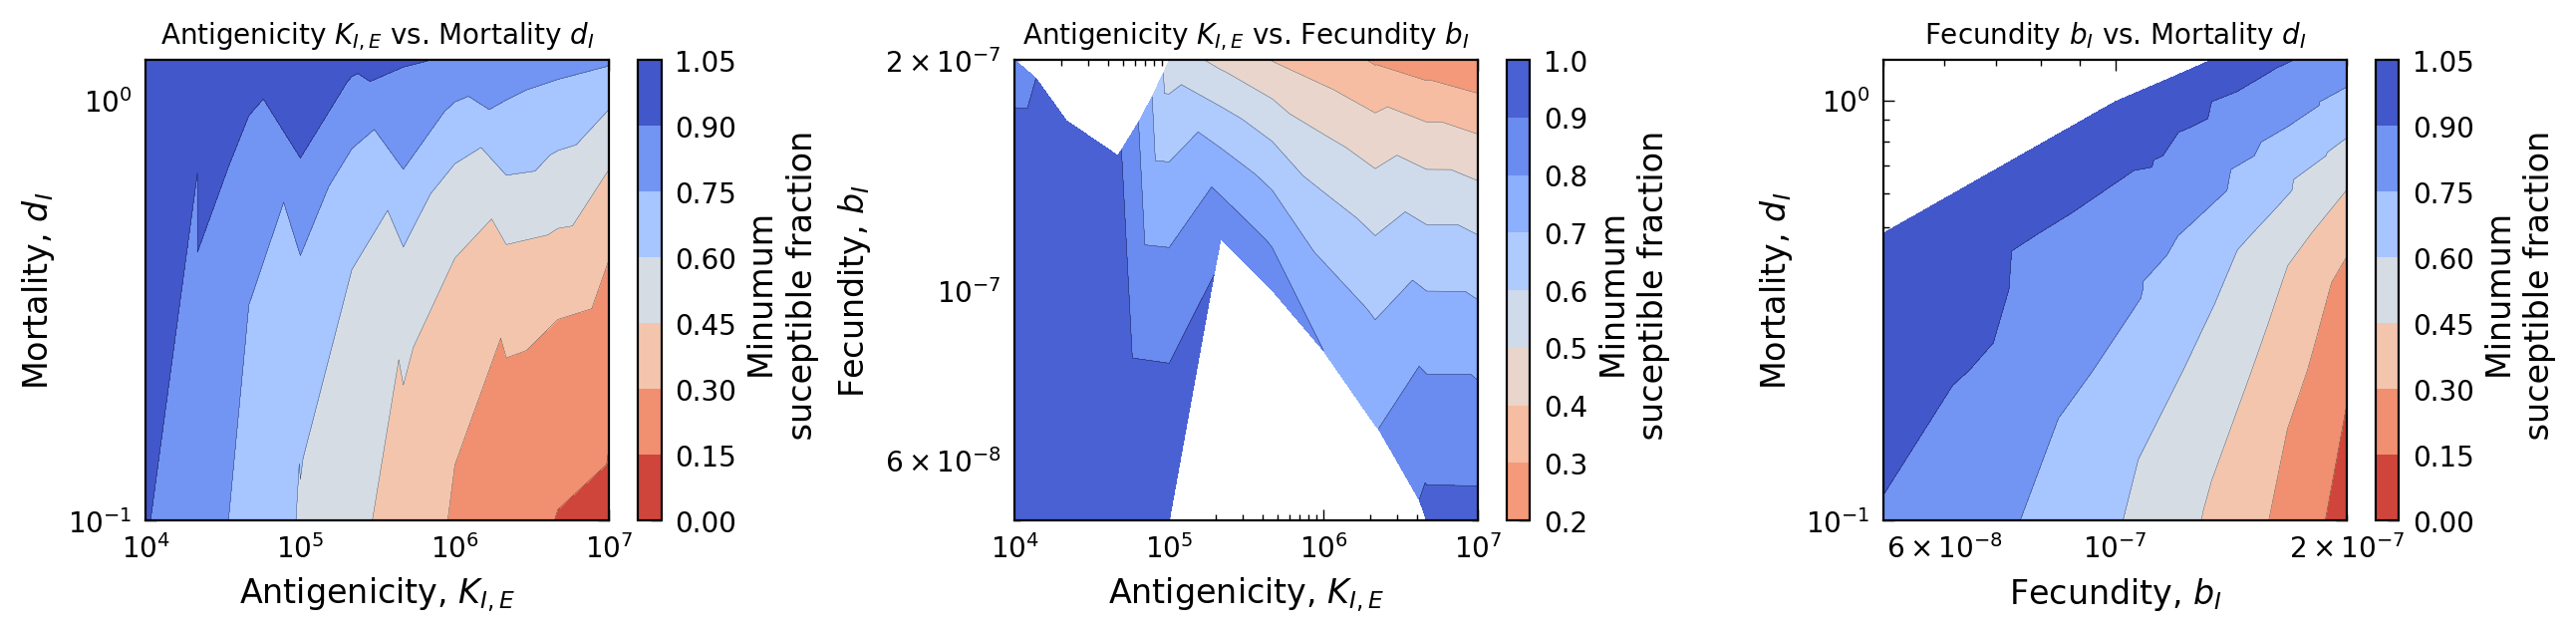

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

axs[0].tricontour(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], 
                  use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], 
                  use_data.groupby(['K_IE','d_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.1, colors='k')
im0 = axs[0].tricontourf(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], 
                        use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], 
                        use_data.groupby(['K_IE','d_I'], as_index=False).mean()['min_pS']/S_0, cmap="coolwarm_r", norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[1].tricontour(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], 
                  use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], 
                  use_data.groupby(['K_IE','b_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.1, colors='k')
im1 = axs[1].tricontourf(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], 
                        use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], 
                        use_data.groupby(['K_IE','b_I'], as_index=False).mean()['min_pS']/S_0, cmap="coolwarm_r", norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[2].tricontour(use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                  use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                  use_data.groupby(['b_I','d_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.1, colors='k')
im2 = axs[2].tricontourf(use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                        use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                        use_data.groupby(['b_I','d_I'], as_index=False).mean()['min_pS']/S_0, cmap="coolwarm_r",norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Fecundity $b_I$ vs. Mortality $d_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[2].set_xlabel("Fecundity, $b_I$", fontsize = 12)

for j, ax in enumerate(axs.flat):
    ax.semilogy()
    ax.semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_Smin_contour', dpi=300, bbox_inches='tight')

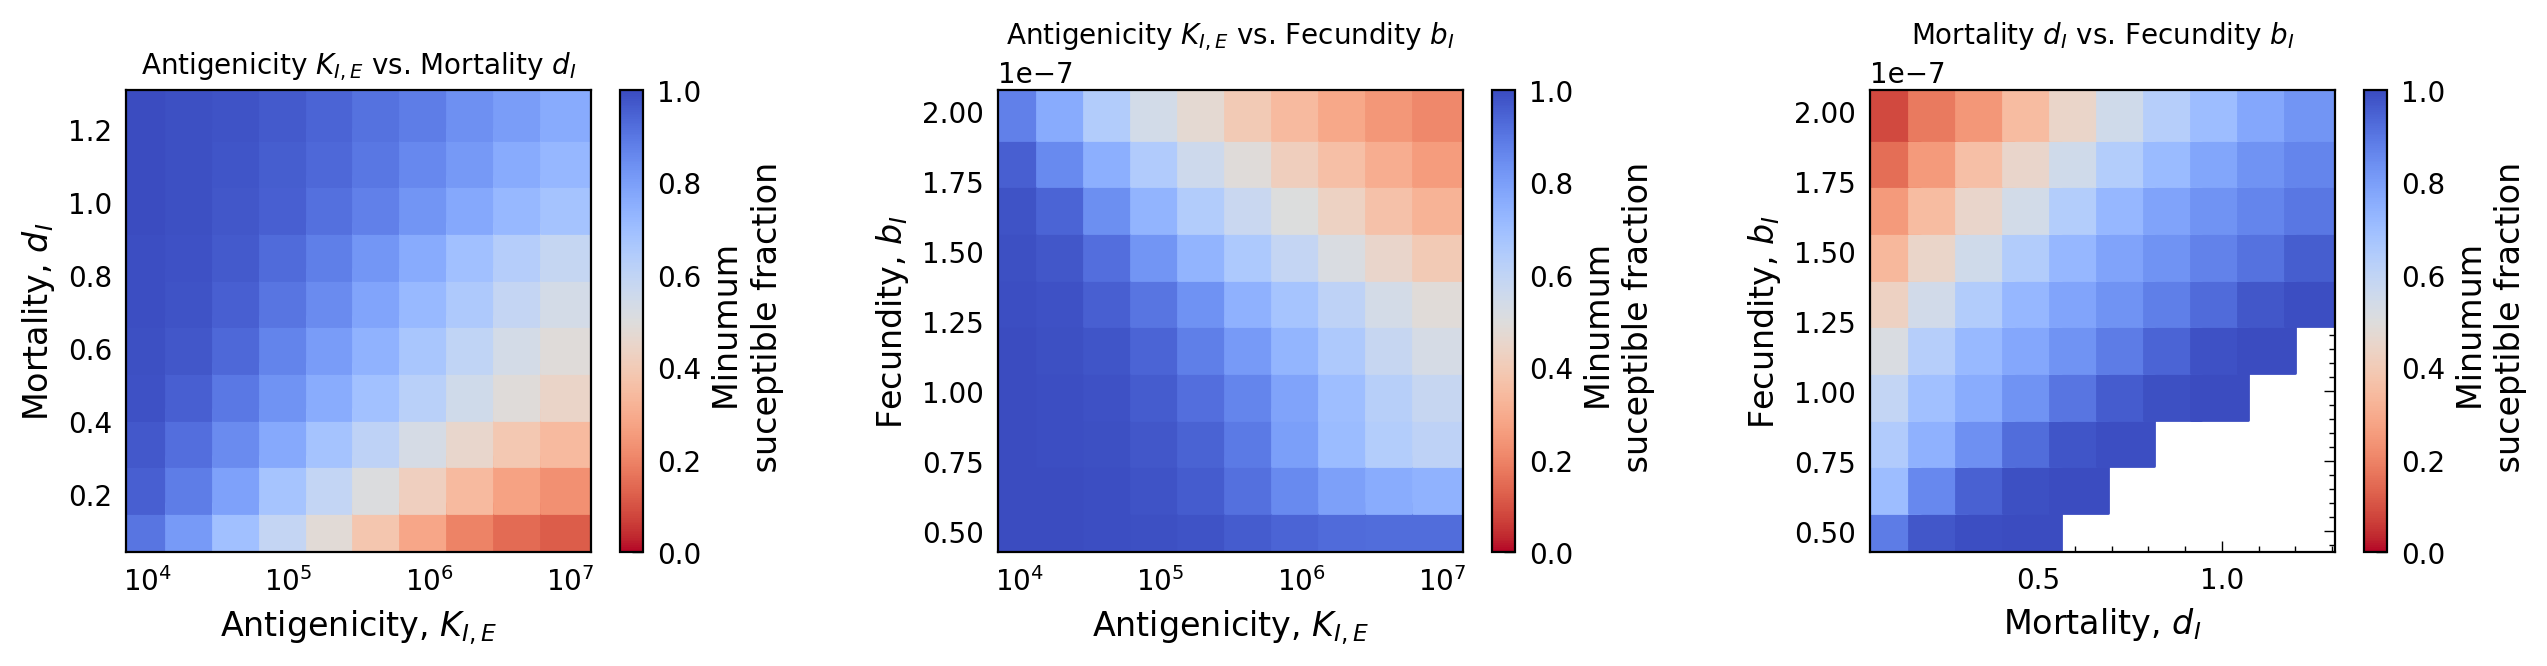

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

size = 4250/num_pnts

plot_data = use_data.groupby(['K_IE','d_I'], as_index=False).mean()
im0 = axs[0].scatter(plot_data['K_IE'], plot_data['d_I'], marker = 's', s = size,
                    c = plot_data['min_pS']/S_0, cmap='coolwarm_r', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
# axs[0].scatter(plot_data.loc[(plot_data['min_pS']/S_0 >= 0.485)*(plot_data['min_pS']/S_0 <= 0.515)]['K_IE'], plot_data.loc[(plot_data['min_pS']/S_0 >= 0.485)*(plot_data['min_pS']/S_0 <= 0.515)]['d_I'], marker = 'o', s = 5,
#                     color ='k')
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

plot_data = use_data.groupby(['K_IE','b_I'], as_index=False).mean()
im1 = axs[1].scatter(plot_data['K_IE'], plot_data['b_I'], marker = 's', s = size,
               c = plot_data['min_pS']/S_0, cmap='coolwarm_r', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

plot_data = use_data.groupby(['b_I','d_I'], as_index=False).mean()
im2 = axs[2].scatter(plot_data['d_I'], plot_data['b_I'], marker = 's', s = size,
               c = plot_data['min_pS']/S_0, cmap='coolwarm_r', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Mortality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Mortality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_Smin_heatmaps', dpi=300, bbox_inches='tight')

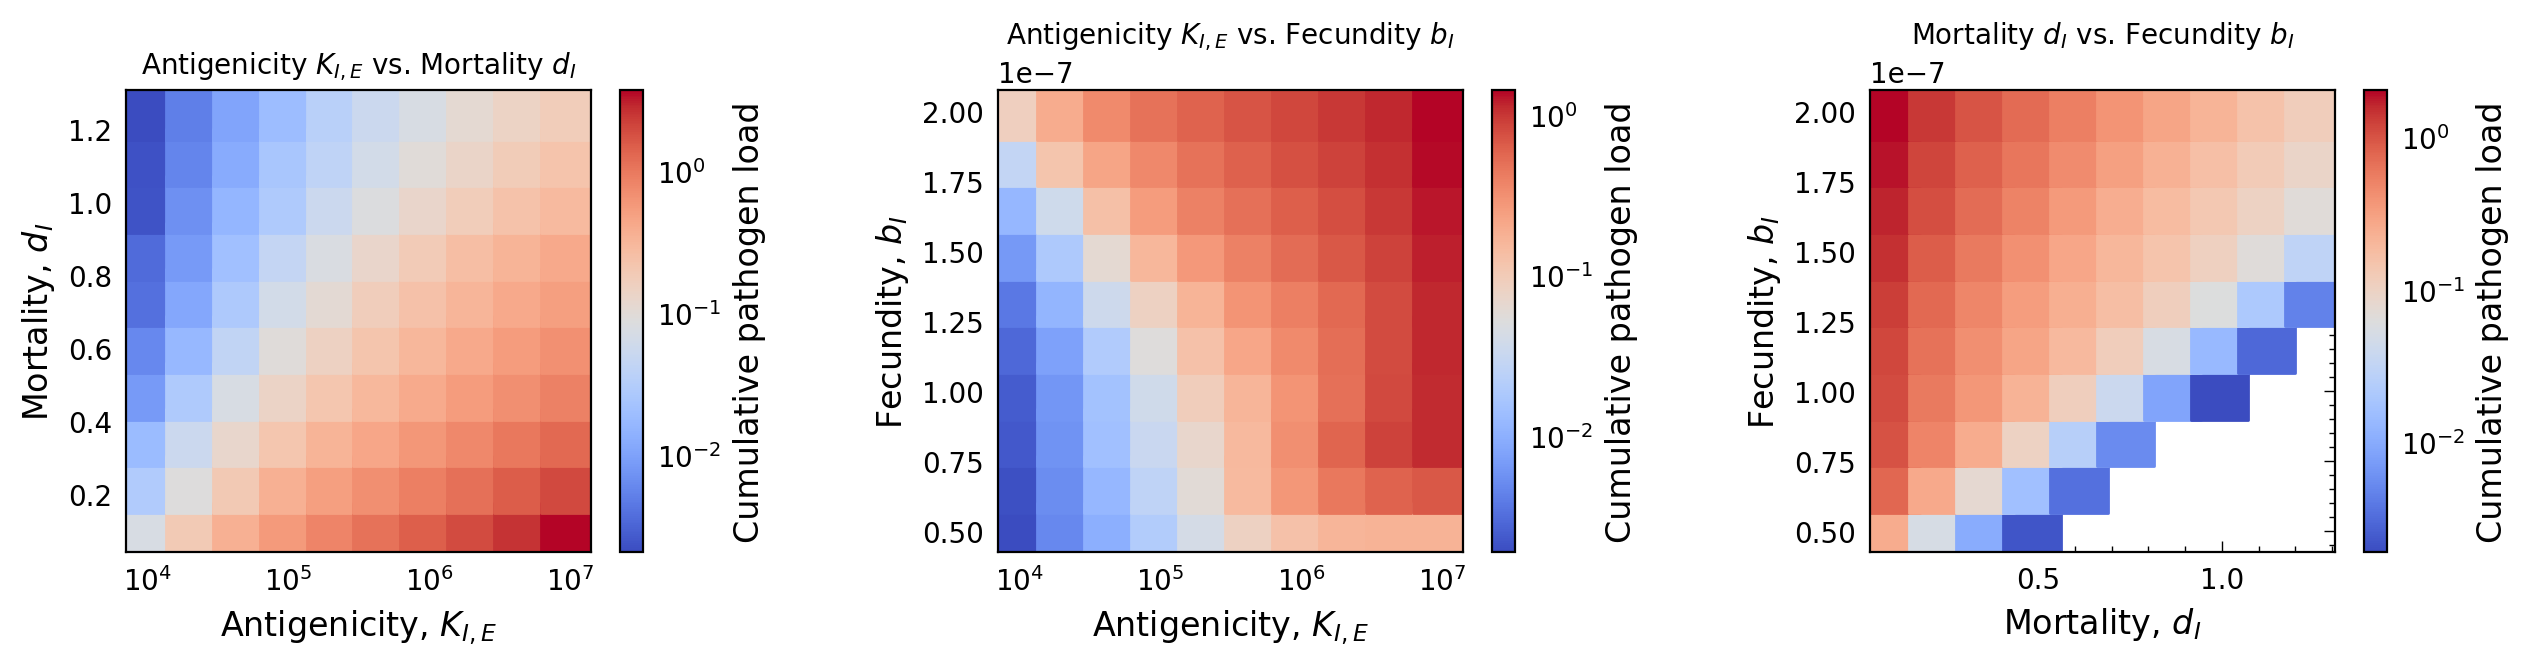

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['p_load']/S_0, cmap='coolwarm', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Cumulative pathogen load", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['p_load']/S_0, cmap='coolwarm', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Cumulative pathogen load", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['p_load']/S_0, cmap='coolwarm', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Cumulative pathogen load", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Mortality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Mortality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_pharm_heatmaps', dpi=300, bbox_inches='tight')

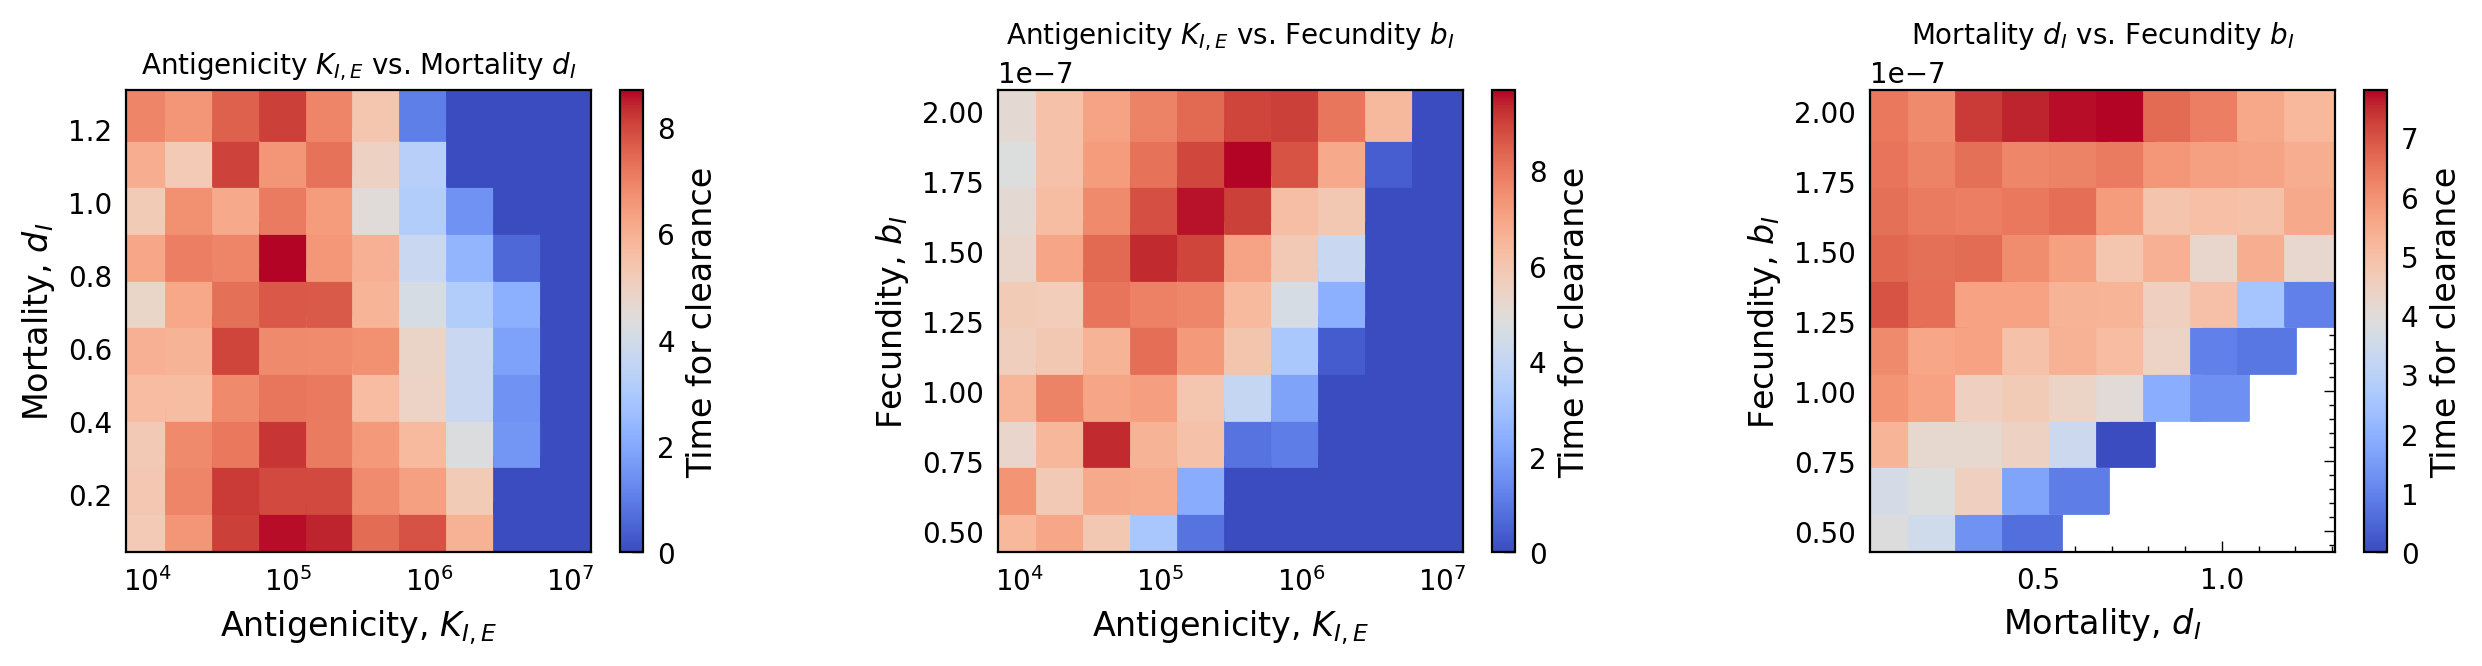

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['T_min_pI'], cmap='coolwarm')
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['T_min_pI'], cmap='coolwarm')
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['T_min_pI'], cmap='coolwarm')
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Mortality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Mortality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_ptiming_heatmaps', dpi=300, bbox_inches='tight')

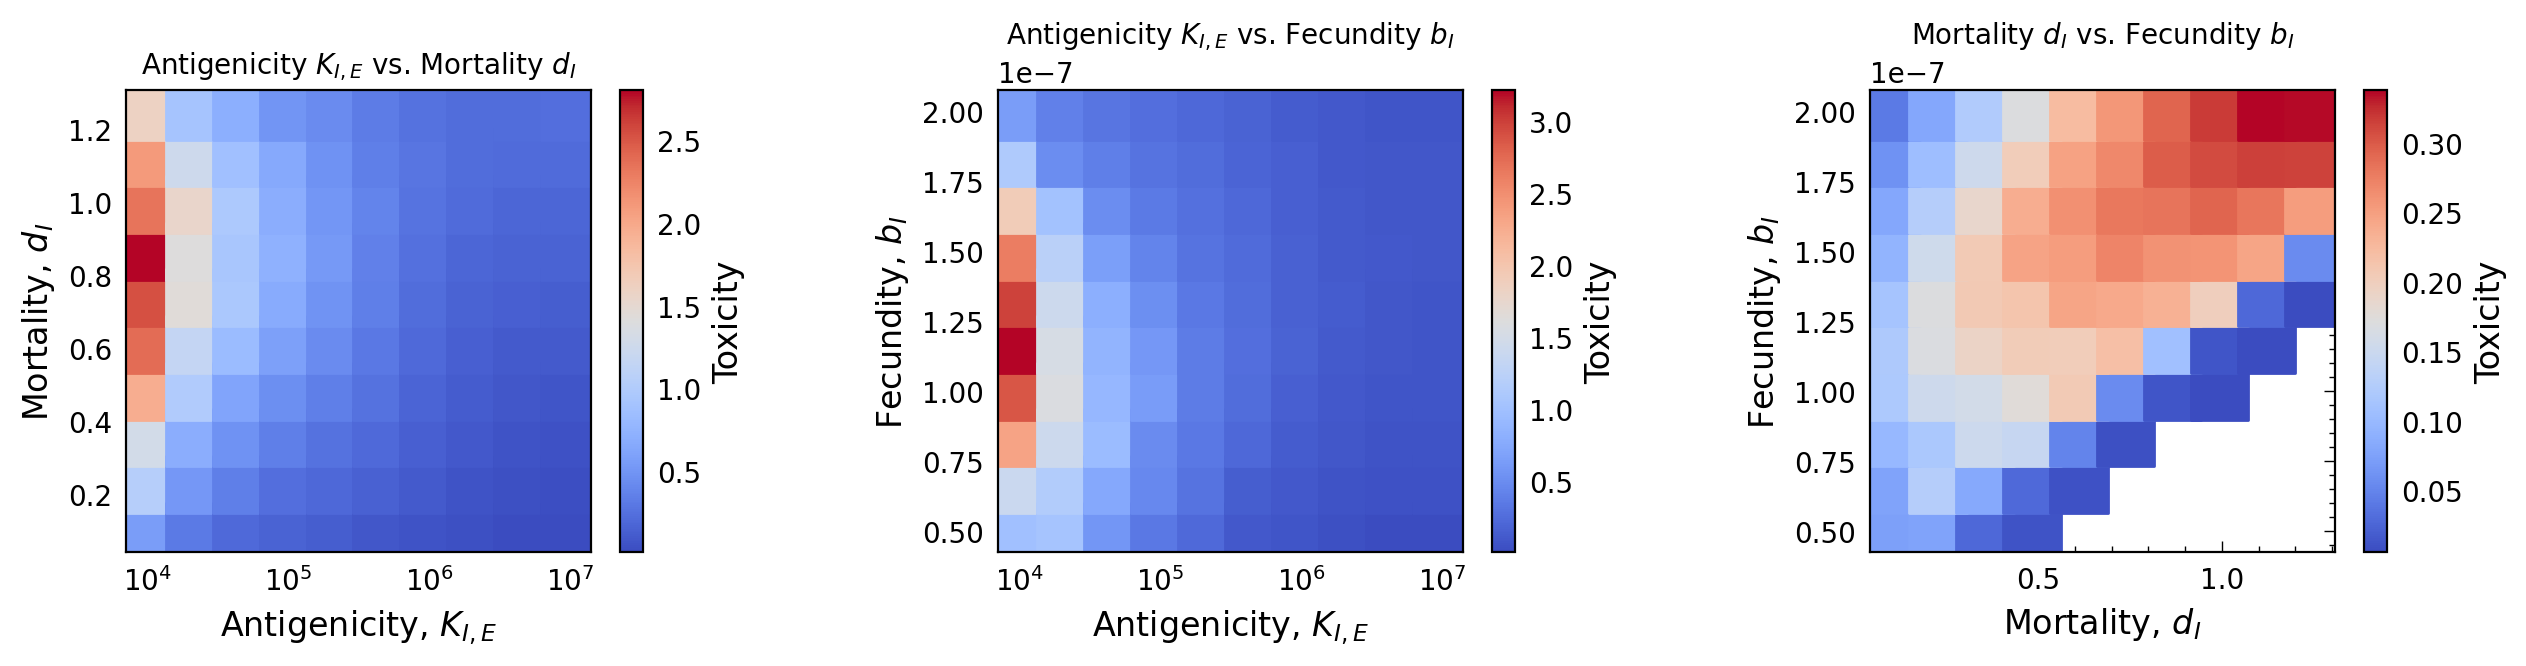

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['harm_pS']/use_data.groupby(['K_IE','d_I'], as_index=False).mean()['harm_pI'], cmap='coolwarm', norm=mpl.colors.Normalize())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['harm_pS']/use_data.groupby(['K_IE','b_I'], as_index=False).mean()['harm_pI'], cmap='coolwarm', norm=mpl.colors.Normalize())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['harm_pS']/use_data.groupby(['b_I','d_I'], as_index=False).mean()['harm_pI'], cmap='coolwarm', norm=mpl.colors.Normalize())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Mortality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Mortality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_toxicity_heatmaps', dpi=300, bbox_inches='tight')

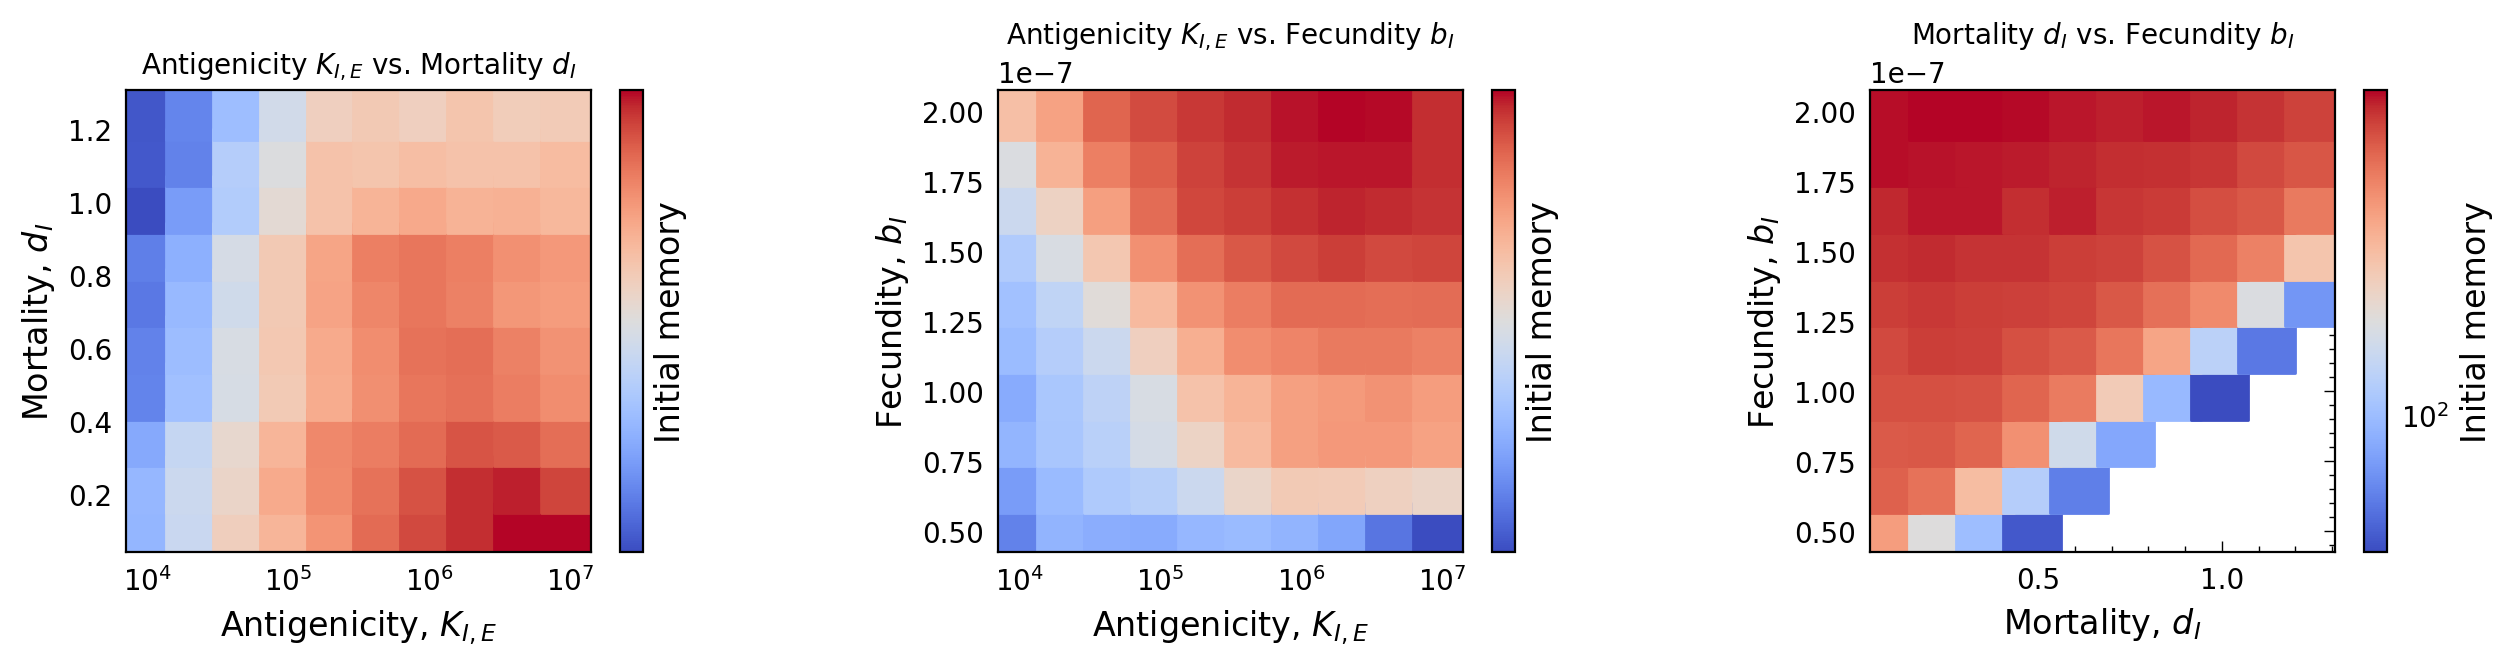

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['max_cM'], cmap='coolwarm', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Initial memory", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['max_cM'], cmap='coolwarm', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Initial memory", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['max_cM'], cmap='coolwarm', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Initial memory", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Mortality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Mortality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_memory_heatmaps', dpi=300, bbox_inches='tight')

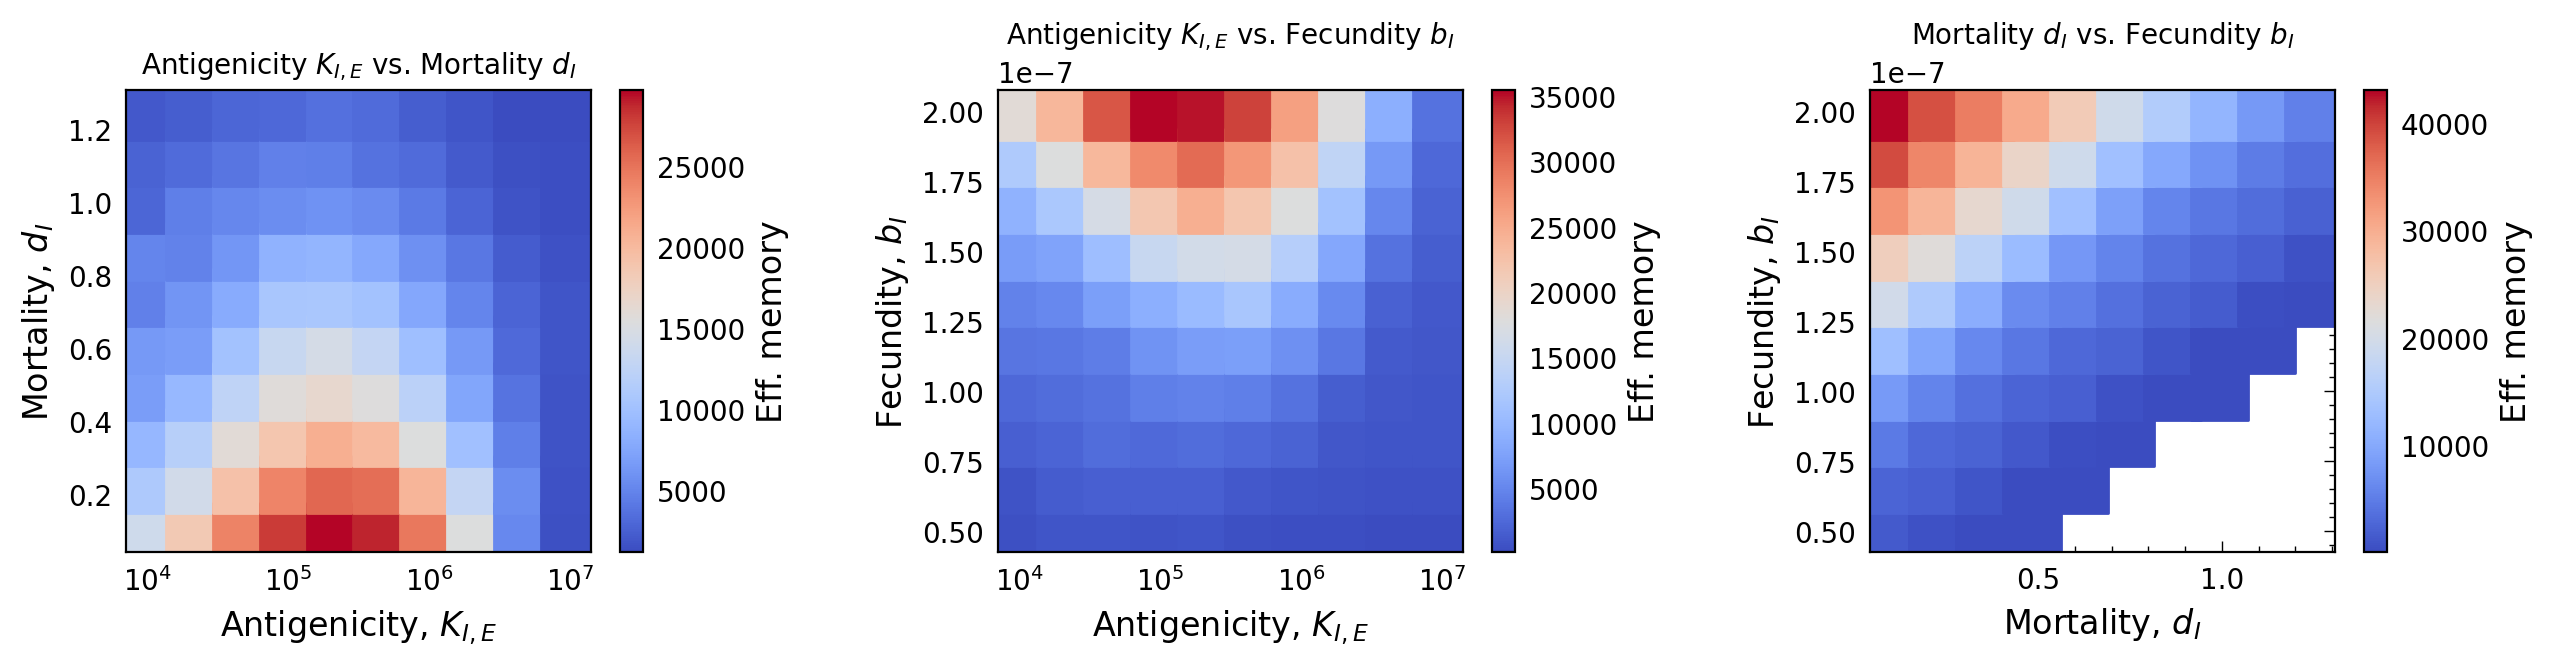

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['max_eM'], cmap='coolwarm', norm=mpl.colors.Normalize())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Eff. memory", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['max_eM'], cmap='coolwarm', norm=mpl.colors.Normalize())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Eff. memory", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['max_eM'], cmap='coolwarm', norm=mpl.colors.Normalize())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Eff. memory", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Mortality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Mortality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_memory_duration_heatmaps', dpi=300, bbox_inches='tight')